In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd

from model import SocialGPModel
from rewards import (
    make_parent_and_children_cholesky2,
    build_corr_matrix_option1,
    _min_max,
)
from tqdm import tqdm


In [3]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [4]:
corr_matrix = build_corr_matrix_option1()
rho_true = corr_matrix[0]
rho_sign_flipped = np.array([1.0, -0.6, 0.0, 0.6])
rho_zero = np.array([1.0, 0.0, 0.0, 0.0])

conditions = {
    "perfectly_calibrated": {
        "label": "SG-ICM\ncalibrated",
        "params": {
            "rho_update_rule": None,
            "rho": rho_true,
            "model_type": "SG-ICM",
        }
    },
    "sign_flipped": {
        "label": "SG-ICM\nflipped",
        "params": {
            "rho_update_rule": None,
            "rho": rho_sign_flipped,
            "model_type": "SG-ICM",
        }
    },
    "asocial": {
        "label": "AS",
        "params": {
            "rho_update_rule": None,
            "rho": rho_zero,
            "model_type": "SG-ICM",
        }
    },
    "rho_kalman": {
        "label": "SG-ICM\nrho kalman",
        "params": {
            "rho_update_rule": "rho_kalman",
            "rho": rho_zero,
            "model_type": "SG-ICM",
        }

    },
    "sg_calibrated": {
        "label": "SG calibrated\n(0.01, 20, 20)",
        "params": {
            "model_type": "SG",
            "rho_update_rule": None,
            "observation_noise_social": [0.01, 20, 20],
            "rho": rho_zero,
        }
    },
    "sg_flipped": {
        "label": "SG flipped\n(20 0.01 0.01)",
        "params": {
            "model_type": "SG",
            "rho_update_rule": None,
            "observation_noise_social": [20, 0.01, 0.01],
            "rho": rho_zero,
        }
    }
}

update_conditions = ["rho_kalman"]


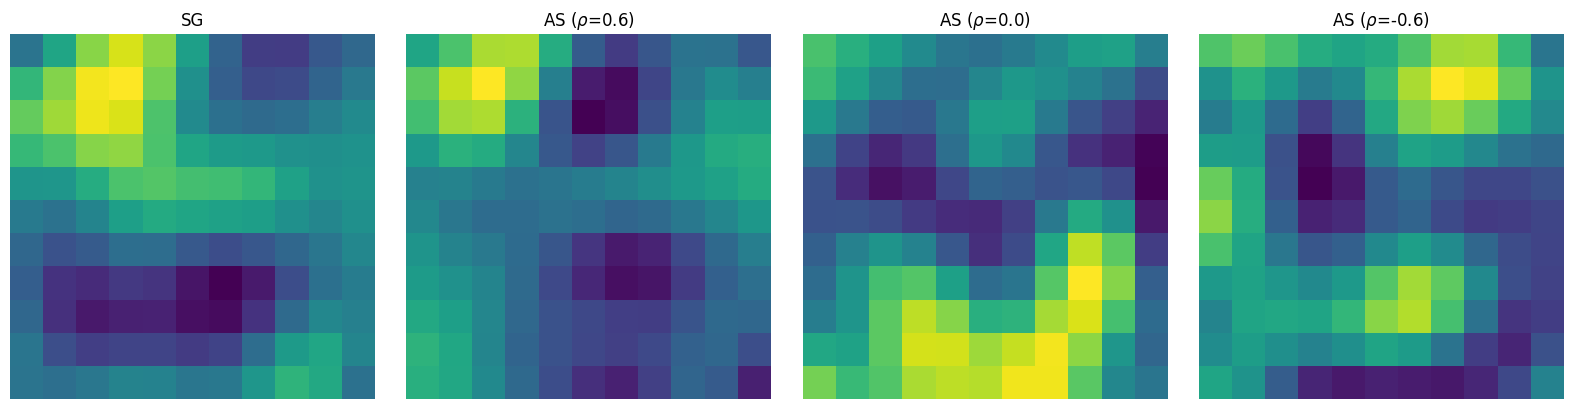

In [5]:
n_children = corr_matrix.shape[0] - 1
seed = 0
a_rng = np.random.default_rng(seed)

grid_size = 11
parent, child_maps = make_parent_and_children_cholesky2(
    rng=a_rng,
    grid_size=grid_size,
    n_children=n_children + 1,
    length_scale=2.0,
    corr_matrix=corr_matrix,
)

child_maps = [_min_max(c) - 0.5 for c in child_maps]

fig, axes = plt.subplots(1, len(child_maps) + 1, figsize=(4 * (len(child_maps) + 1), 4))

axes[0].imshow(_min_max(parent) - 0.5, origin='lower')
axes[0].set_title("SG")
axes[0].axis('off')

for _corr, c, ax in zip([0.6, 0.0, -0.6], child_maps, axes[1:]):
    ax.imshow(c, origin='lower')
    ax.set_title(fr"AS ($\rho$={_corr})")
    ax.axis('off')

plt.tight_layout()
plt.show()


## Run the model


In [6]:
m = SocialGPModel(
    n=n_children + 1,
    model_type="SG-ICM",
    child_maps=[parent] + child_maps,
    network_type="directed_one_to_four",
    rho=rho_zero,
    rho_update_rule="rho_kalman",
    rho_update_init=0.0,
    rho_update_sigma_zeta=1e-4,
    rho_update_basis="private",
    tau_sampling=True,
    beta_sampling=True,
    length_scale_sampling=True,
)

for _ in range(15):
    m.step()

results = m.datacollector.get_agent_vars_dataframe().reset_index()
results.head(20)


,Step,AgentID,choice,reward,cumulative_reward,model_type,tau,neg_log_likelihood,last_choice_distance_private,avg_choice_distance_private,nearest_choice_distance_private,last_choice_distance_social,avg_choice_distance_social,nearest_choice_distance_social
0,1,1,"(4, 9)",0.156252,0.156252,SG-ICM,0.042922,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,2,"(7, 7)",-0.080413,-0.080413,AS,0.042922,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,1,3,"(8, 1)",-0.107780,-0.107780,AS,0.042922,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,1,4,"(9, 0)",0.031942,0.031942,AS,0.042922,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2,1,"(3, 4)",-0.821178,-0.664926,SG-ICM,0.042922,4.783843,5.099020,5.099020,5.099020,6.014018,6.014018,5.000000
5,2,2,"(5, 1)",-0.120943,-0.201356,AS,0.042922,4.781579,6.324555,6.324555,6.324555,0.000000,0.000000,0.000000
6,2,3,"(4, 9)",0.255503,0.147724,AS,0.042922,4.781327,8.944272,8.944272,8.944272,0.000000,0.000000,0.000000
7,2,4,"(7, 10)",-0.146244,-0.114302,AS,0.042922,4.783869,10.198039,10.198039,10.198039,0.000000,0.000000,0.000000
8,3,1,"(3, 2)",-0.963117,-1.628043,SG-ICM,0.042922,4.763288,2.000000,4.535534,2.000000,6.083803,6.013018,2.236068
9,3,2,"(9, 6)",-0.471544,-0.672900,AS,0.042922,4.766785,6.403124,4.319596,2.236068,0.000000,0.000000,0.000000


In [16]:
def generate_env(env_seed, rho, grid_size=11, max_tries=100, tol: float = 0.10):
    rng = np.random.default_rng(env_seed)
    for _ in range(max_tries):
        parent, child_maps = make_parent_and_children_cholesky2(
            rng=rng,
            grid_size=grid_size,
            n_children=n_children + 1,
            length_scale=2.0,
            corr_matrix=corr_matrix,
        )
        flats = [c.ravel() for c in [parent] + child_maps]
        C = np.corrcoef(flats)
        ok = np.all(
            np.abs(C[0, :] - rho) <= tol
        )
        if ok:
            break
    child_maps = [_min_max(c) - 0.5 for c in child_maps]
    return parent, child_maps


def get_agent0_rho(model):
    agent = model.grid.agents[0]
    neighbors = [n.agents[0].unique_id for n in model.grid[agent.cell.coordinate].neighborhood]
    if agent._rho_updater is None:
        return np.array(agent.rho, dtype=float)
    return agent._rho_updater.get_rho_vector(neighbors)


def run_condition(condition_name, condition_cfg, parent, child_maps, n_steps=15, seed=0):
    m = SocialGPModel(
        n=n_children + 1,
        child_maps=[parent] + child_maps,
        network_type="directed_one_to_four",
        rho_update_init=0.0,
        rho_update_sigma_zeta=1e-4,
        rho_update_basis="full", # private/full
        # tau_sampling=True,
        # beta_sampling=True,
        # length_scale_sampling=True,
        tau=0.03,
        beta_private=0.33,
        length_scale_private=1.11,
        length_scale_is_identical=True,
        seed=seed,
        **condition_cfg["params"]
    )

    rho_history = []
    for _ in range(n_steps):
        m.step()
        rho_history.append(get_agent0_rho(m))

    df = m.datacollector.get_agent_vars_dataframe().reset_index()
    df["condition"] = condition_name
    df["condition_label"] = condition_cfg["label"]
    df["seed"] = seed
    return df, np.array(rho_history)


In [15]:
n_envs = 1_000
n_steps = 15

all_results = []
rho_histories = []

for env_seed in tqdm(range(n_envs)):
    parent, child_maps = generate_env(env_seed, np.array([1, 0.6, 0.0, -0.6]), grid_size=grid_size)
    for condition_name, condition_cfg in conditions.items():
        df, rho_hist = run_condition(
            condition_name,
            condition_cfg,
            parent,
            child_maps,
            n_steps=n_steps,
            seed=env_seed,
        )
        all_results.append(df)
        rho_histories.append(
            {
                "condition": condition_name,
                "condition_label": condition_cfg["label"],
                "seed": env_seed,
                "rho_history": rho_hist,
            }
        )

results = pd.concat(all_results, ignore_index=True)
results.head()


  0%|          | 0/100 [00:00<?, ?it/s]

[ 1.          0.5117822  -0.02339151 -0.54817246]


  2%|▏         | 2/100 [00:00<00:23,  4.10it/s]

[ 1.          0.69714719  0.0693201  -0.5431791 ]
[ 1.          0.68461513  0.03221867 -0.61815061]


  4%|▍         | 4/100 [00:00<00:22,  4.36it/s]

...

[ 1.          0.50090592 -0.05388534 -0.59062622]


 99%|█████████▉| 99/100 [00:23<00:00,  4.43it/s]

[ 1.00000000e+00  6.75825557e-01 -5.49421661e-04 -6.62380713e-01]


100%|██████████| 100/100 [00:23<00:00,  4.24it/s]


,Step,AgentID,choice,reward,cumulative_reward,model_type,tau,neg_log_likelihood,last_choice_distance_private,avg_choice_distance_private,nearest_choice_distance_private,last_choice_distance_social,avg_choice_distance_social,nearest_choice_distance_social,condition,condition_label,seed
0,1,1,"(9, 9)",0.446368,0.446368,SG-ICM,0.03,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.0,perfectly_calibrated,SG-ICM\ncalibrated,0
1,1,2,"(5, 4)",0.359409,0.359409,AS,0.03,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.0,perfectly_calibrated,SG-ICM\ncalibrated,0
2,1,3,"(9, 8)",0.493539,0.493539,AS,0.03,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.0,perfectly_calibrated,SG-ICM\ncalibrated,0
3,1,4,"(3, 10)",-0.338839,-0.338839,AS,0.03,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.0,perfectly_calibrated,SG-ICM\ncalibrated,0
4,2,1,"(3, 10)",0.033734,0.480102,SG-ICM,0.03,0.058943,6.082763,6.082763,6.082763,4.21637,4.21637,0.0,perfectly_calibrated,SG-ICM\ncalibrated,0


In [18]:
# parallelized version
from joblib import Parallel, delayed

def process_one_seed(env_seed):
    # These lists will hold results just for this one seed
    local_results = []
    local_rhos = []

    parent, child_maps = generate_env(env_seed, np.array([1, 0.6, 0.0, -0.6]), grid_size=grid_size)

    for condition_name, condition_cfg in conditions.items():
        df, rho_hist = run_condition(
            condition_name,
            condition_cfg,
            parent,
            child_maps,
            n_steps=n_steps,
            seed=env_seed,
        )
        local_results.append(df)
        local_rhos.append(
            {
                "condition": condition_name,
                "condition_label": condition_cfg["label"],
                "seed": env_seed,
                "rho_history": rho_hist,
            }
        )
    # Return the data for this specific seed
    return local_results, local_rhos

n_envs = 1_000
n_steps = 15

parallel_outputs = Parallel(n_jobs=-1)(
    delayed(process_one_seed)(seed) for seed in tqdm(range(n_envs))
)

all_results = []
rho_histories = []

for seed_dfs, seed_rhos in parallel_outputs:
    all_results.extend(seed_dfs)
    rho_histories.extend(seed_rhos)

results = pd.concat(all_results, ignore_index=True)
results.head()


100%|██████████| 1000/1000 [01:23<00:00, 11.94it/s]


,Step,AgentID,choice,reward,cumulative_reward,model_type,tau,neg_log_likelihood,last_choice_distance_private,avg_choice_distance_private,nearest_choice_distance_private,last_choice_distance_social,avg_choice_distance_social,nearest_choice_distance_social,condition,condition_label,seed
0,1,1,"(9, 9)",0.446368,0.446368,SG-ICM,0.03,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.0,perfectly_calibrated,SG-ICM\ncalibrated,0
1,1,2,"(5, 4)",0.359409,0.359409,AS,0.03,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.0,perfectly_calibrated,SG-ICM\ncalibrated,0
2,1,3,"(9, 8)",0.493539,0.493539,AS,0.03,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.0,perfectly_calibrated,SG-ICM\ncalibrated,0
3,1,4,"(3, 10)",-0.338839,-0.338839,AS,0.03,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.0,perfectly_calibrated,SG-ICM\ncalibrated,0
4,2,1,"(3, 10)",0.033734,0.480102,SG-ICM,0.03,0.058943,6.082763,6.082763,6.082763,4.21637,4.21637,0.0,perfectly_calibrated,SG-ICM\ncalibrated,0


In [19]:
def _select_sg_agent(df):
    plot_df = df.copy()
    if "model_type" in plot_df.columns:
        sg = plot_df[(plot_df["model_type"] == "SG-ICM") | (plot_df["model_type"] == "SG")].copy()
        if not sg.empty:
            return sg
    if "AgentID" in plot_df.columns:
        min_id = plot_df["AgentID"].min()
        return plot_df[plot_df["AgentID"] == min_id].copy()
    return plot_df


def plot_reward(df, y_col="reward", keep_labels=None, figsize=(9, 5)):
    plot_df = _select_sg_agent(df)
    plot_df = plot_df.dropna(subset=["Step", y_col, "condition_label"])
    if plot_df.empty:
        print("No data available for plot_reward.")
        return

    if keep_labels:
        plot_df = plot_df[plot_df["condition_label"].isin(keep_labels)]
        hue_order = keep_labels
    else:
        hue_order = sorted(plot_df["condition_label"].unique())

    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=plot_df,
        x="Step",
        y=y_col,
        hue="condition_label",
        hue_order=hue_order,
        ax=ax,
    )
    ax.set_title(f"{y_col.replace('_', ' ').title()} for SG-ICM agent")
    ax.set_xlabel("Step")
    ax.set_ylabel(y_col.replace("_", " " ).title())
    ax.legend(
        title="Condition",
        bbox_to_anchor=(1.02, 0.5),
        loc="center left",
        borderaxespad=0,
    )
    plt.tight_layout()
    plt.show()


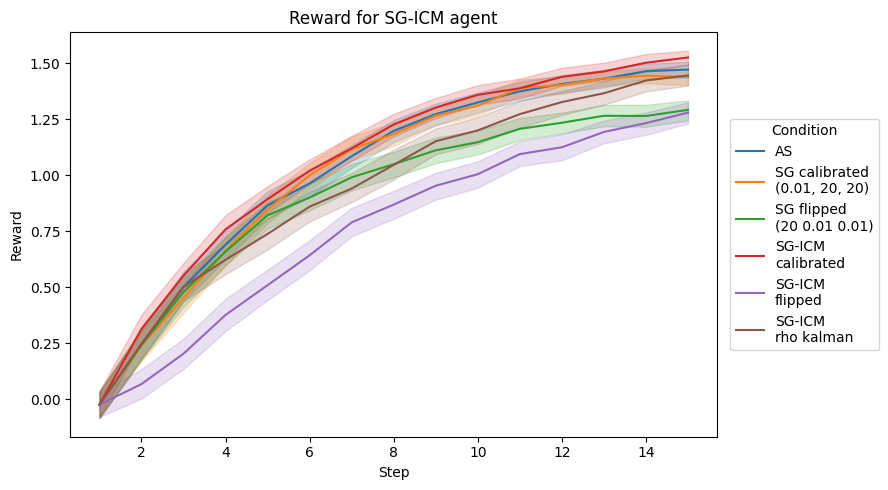

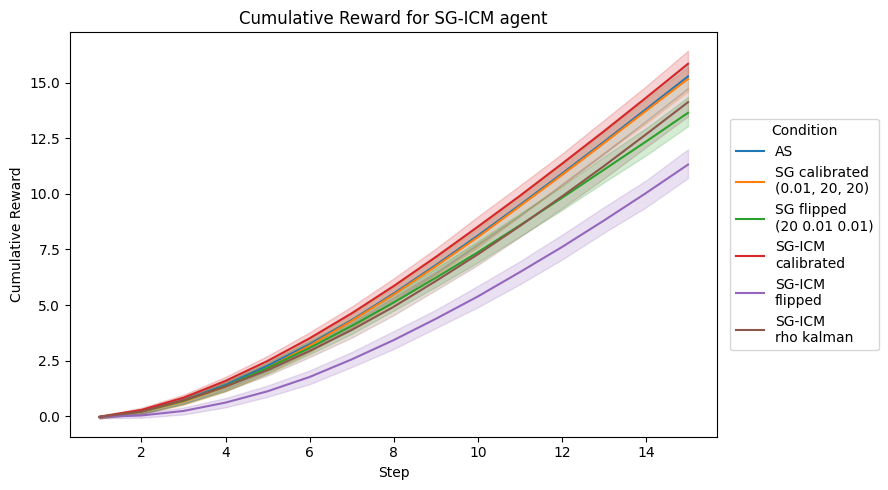

In [20]:
plot_reward(results, y_col="reward")
plot_reward(results, y_col="cumulative_reward")

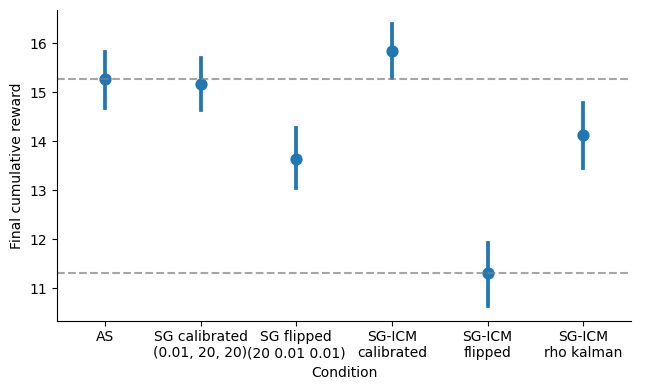

In [21]:
def plot_final_cumreward_catplot(df, x='condition_label'):
    plot_df = _select_sg_agent(df)
    if plot_df.empty:
        print("No data available for plot_final_cumreward_catplot.")
        return

    group_cols = ["seed"]
    if x in plot_df.columns:
        group_cols.append(x)
    final_step = plot_df.groupby(group_cols)["Step"].transform('max')
    last = plot_df[plot_df['Step'] == final_step].copy()
    last = last.dropna(subset=[x, 'cumulative_reward'])
    if last.empty:
        print("No final-step data to plot.")
        return

    sns.catplot(
        data=last,
        kind='point',
        x=x,
        y='cumulative_reward',
        order=sorted(last[x].unique()),
        height=4,
        aspect=1.6,
        linestyle='none',
        estimator='mean',
        errorbar=('ci', 95)
    )

    as_mean = last.loc[last[x] == "AS", "cumulative_reward"].mean()
    flipped_mean = last.loc[last[x] == "SG-ICM\nflipped", "cumulative_reward"].mean()

    if pd.notna(as_mean):
        plt.axhline(y=as_mean, color='gray', linestyle='--', label='AS Mean', alpha=0.7)

    if pd.notna(flipped_mean):
        plt.axhline(y=flipped_mean, color='gray', linestyle='--', label='SG-ICM flipped Mean', alpha=0.7)

    plt.xticks(rotation=0)
    plt.xlabel('Condition')
    plt.ylabel('Final cumulative reward')
    plt.tight_layout()
    plt.show()

plot_final_cumreward_catplot(results)


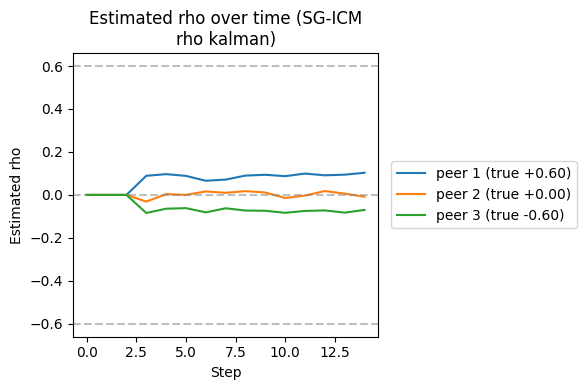

In [22]:
def mean_rho_history(condition):
    histories = [
        entry["rho_history"]
        for entry in rho_histories
        if entry["condition"] == condition
    ]
    if not histories:
        return None
    return np.mean(np.stack(histories, axis=0), axis=0)

true_rho = rho_true[1:]

fig, axes = plt.subplots(1, len(update_conditions), figsize=(6 * len(update_conditions), 4))
if len(update_conditions) == 1:
    axes = [axes]

for ax, condition in zip(axes, update_conditions):
    mean_hist = mean_rho_history(condition)
    if mean_hist is None:
        continue

    for idx, rho_t in enumerate(true_rho):
        ax.plot(mean_hist[:, idx + 1], label=f"peer {idx+1} (true {rho_t:+.2f})")
        ax.axhline(rho_t, linestyle='--', color='gray', alpha=0.5)

    ax.set_title(f"Estimated rho over time ({conditions[condition]['label']})")
    ax.set_xlabel("Step")
    ax.set_ylabel("Estimated rho")
    ax.legend(bbox_to_anchor=(1.02, 0.5), loc="center left")

plt.tight_layout()
plt.show()


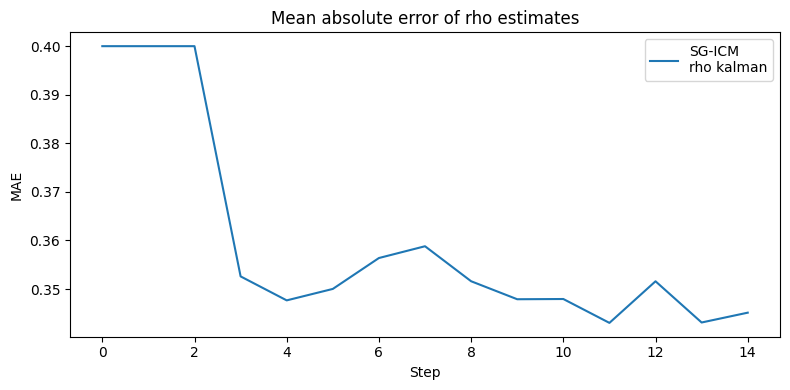

In [23]:
def rho_mae(history):
    est = history[:, 1:]
    return np.mean(np.abs(est - true_rho), axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
for condition in update_conditions:
    mean_hist = mean_rho_history(condition)
    if mean_hist is None:
        continue
    ax.plot(rho_mae(mean_hist), label=conditions[condition]["label"])

ax.set_title("Mean absolute error of rho estimates")
ax.set_xlabel("Step")
ax.set_ylabel("MAE")
ax.legend()
plt.tight_layout()
plt.show()
